# Module 6 — Multi-Panel Figures

This module is the matplotlib equivalent of `facet_wrap()` and `facet_grid()` in ggplot2, except matplotlib does not auto-facet. You decide the grid, then populate each cell.

More work, more control.

The mental model:

```text
┌──────────────────────────────────────────────────────────┐
│ A Figure can hold many Axes objects in a layout.         │
│ You choose the layout, then draw on each Axes one at     │
│ a time. Each Axes is independent: its own data, title,   │
│ ticks, colors, and annotations.                          │
└──────────────────────────────────────────────────────────┘
```

Matplotlib gives several ways to lay out multiple panels, in increasing order of flexibility:

1. `plt.subplots(nrows, ncols)` — regular grid; useful for most cases
2. `subplot_mosaic("AB;CC")` — named, irregular grid; modern favorite
3. `GridSpec` — full control over rows, columns, and spans
4. `fig.add_axes([x, y, w, h])` — place an `Axes` at exact coordinates

Start with `plt.subplots()`. Use `subplot_mosaic()` when the layout becomes irregular. Learn `GridSpec` when `subplot_mosaic()` is not enough. Use `fig.add_axes()` mostly for inset plots.

## 1. `plt.subplots()` for regular grids

The common pattern is to create a `Figure` plus an array of `Axes` objects.

(2, 3)


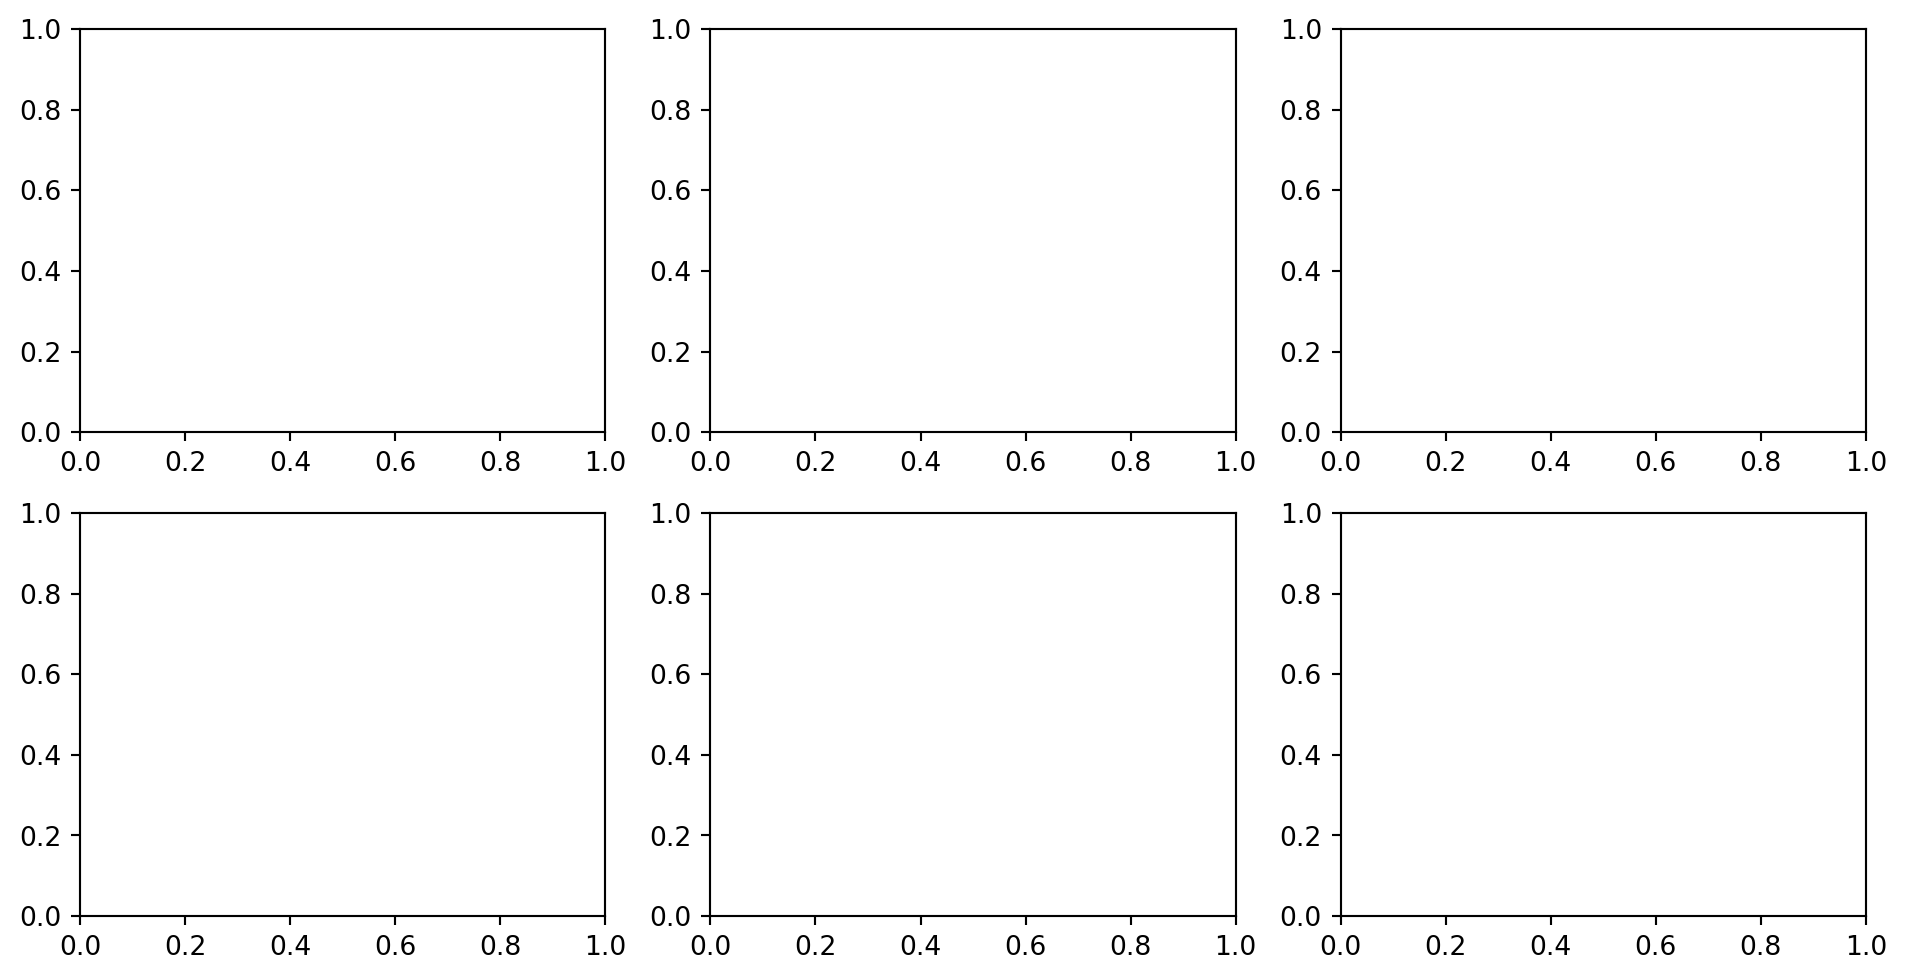

In [1]:
import matplotlib.pyplot as plt
import numpy as np

fig, axes = plt.subplots(nrows=2, ncols=3, figsize=(12, 6))
print(axes.shape)
plt.show()

For `plt.subplots(2, 3)`, `axes` is a 2D NumPy array of `Axes` objects with shape `(2, 3)`. Individual panels are accessed by indexing.

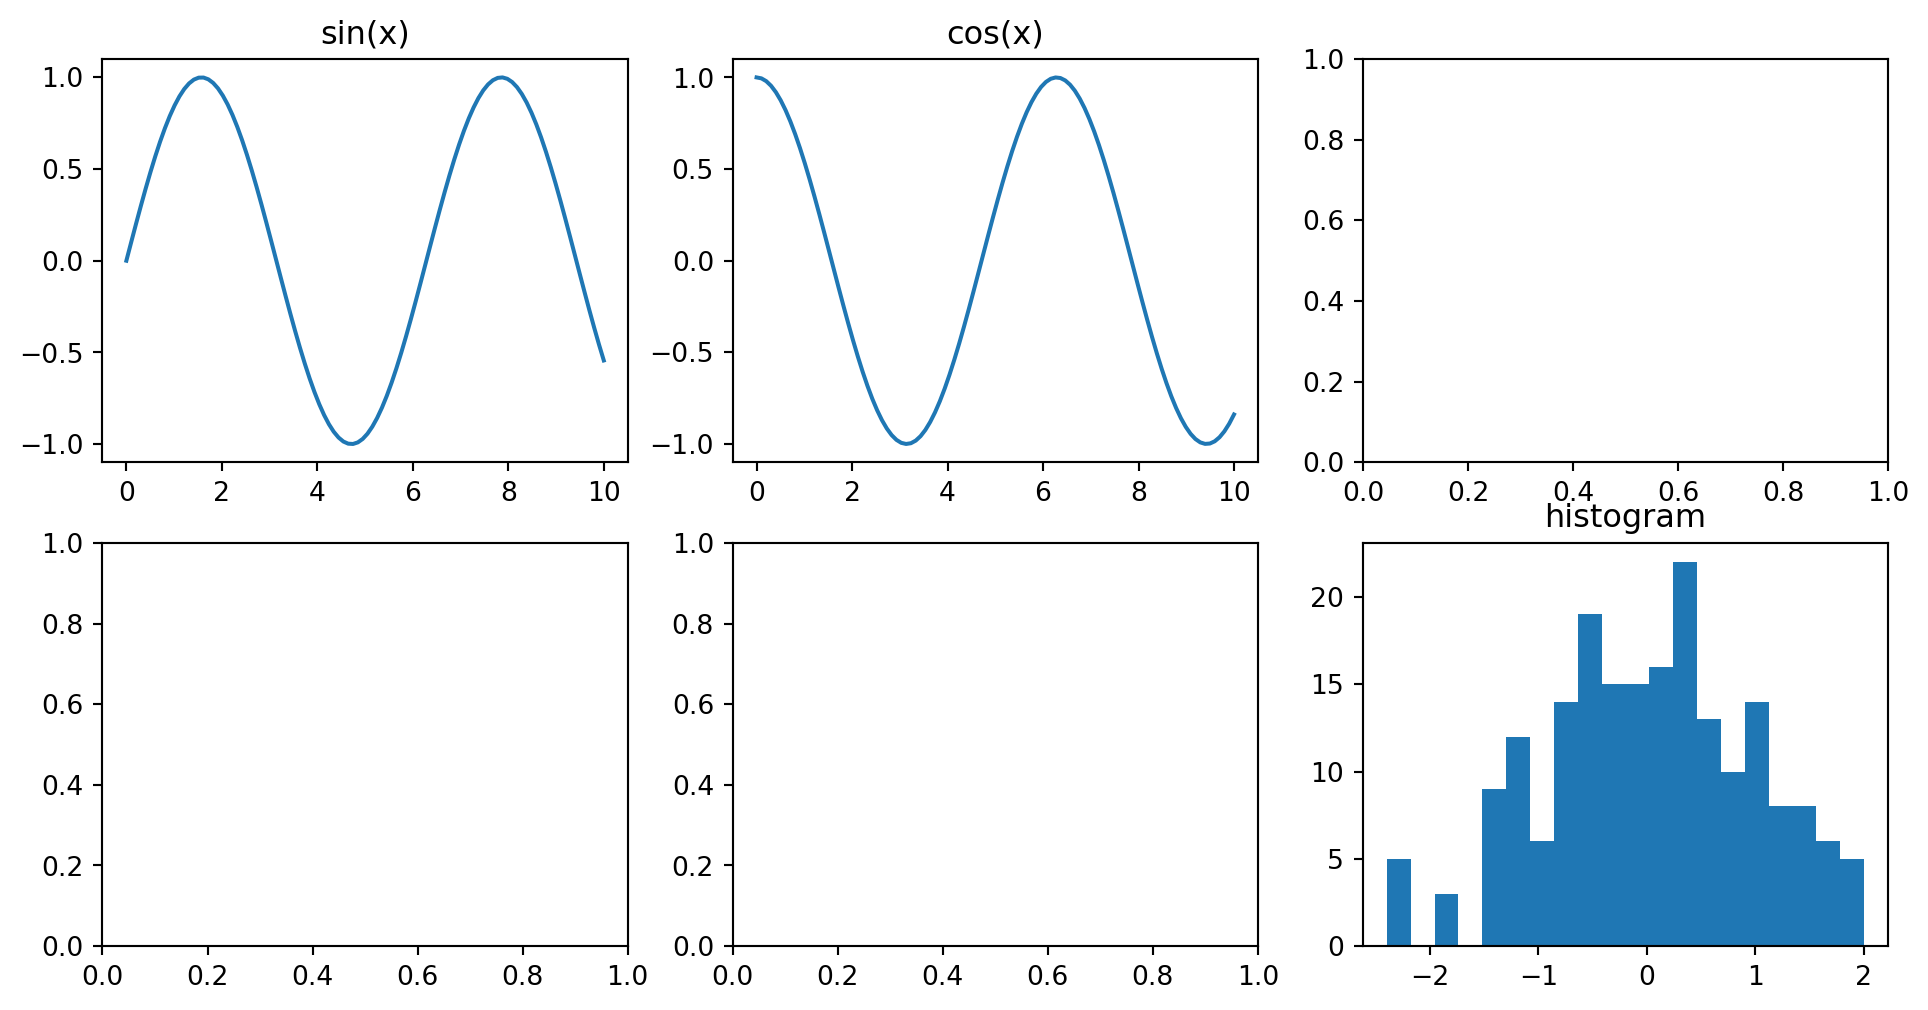

In [2]:
x = np.linspace(0, 10, 100)
rng = np.random.default_rng(0)

fig, axes = plt.subplots(nrows=2, ncols=3, figsize=(12, 6))

axes[0, 0].plot(x, np.sin(x))
axes[0, 0].set_title("sin(x)")

axes[0, 1].plot(x, np.cos(x))
axes[0, 1].set_title("cos(x)")

axes[1, 2].hist(rng.normal(size=200), bins=20)
axes[1, 2].set_title("histogram")

plt.show()

The shape of `axes` for `plt.subplots(2, 3)`:

```text
                  col 0        col 1        col 2
              ┌─────────┐  ┌─────────┐  ┌─────────┐
row 0         │axes[0,0]│  │axes[0,1]│  │axes[0,2]│
              └─────────┘  └─────────┘  └─────────┘
              ┌─────────┐  ┌─────────┐  ┌─────────┐
row 1         │axes[1,0]│  │axes[1,1]│  │axes[1,2]│
              └─────────┘  └─────────┘  └─────────┘
```

### The single-row / single-column gotcha

When `nrows=1` or `ncols=1`, the returned `axes` object may not be 2D.

```python
fig, axes = plt.subplots(1, 3)  # shape (3,), a 1D array
axes[0].plot(...)              # works
axes[0, 0].plot(...)           # IndexError

fig, axes = plt.subplots(1, 1)  # a single Axes, not an array
axes.plot(...)                  # works
axes[0].plot(...)               # TypeError
```

Two ways to avoid thinking about this too much:

```python
# Option A: always return a 2D array
fig, axes = plt.subplots(1, 3, squeeze=False)  # shape (1, 3)

# Option B: flatten and iterate
fig, axes = plt.subplots(2, 3)
for ax in axes.flat:
    ax.set_xlabel("x")
```

`axes.flat` gives a 1D iterator over all panels, regardless of grid shape. It is very useful for loop-driven plotting.

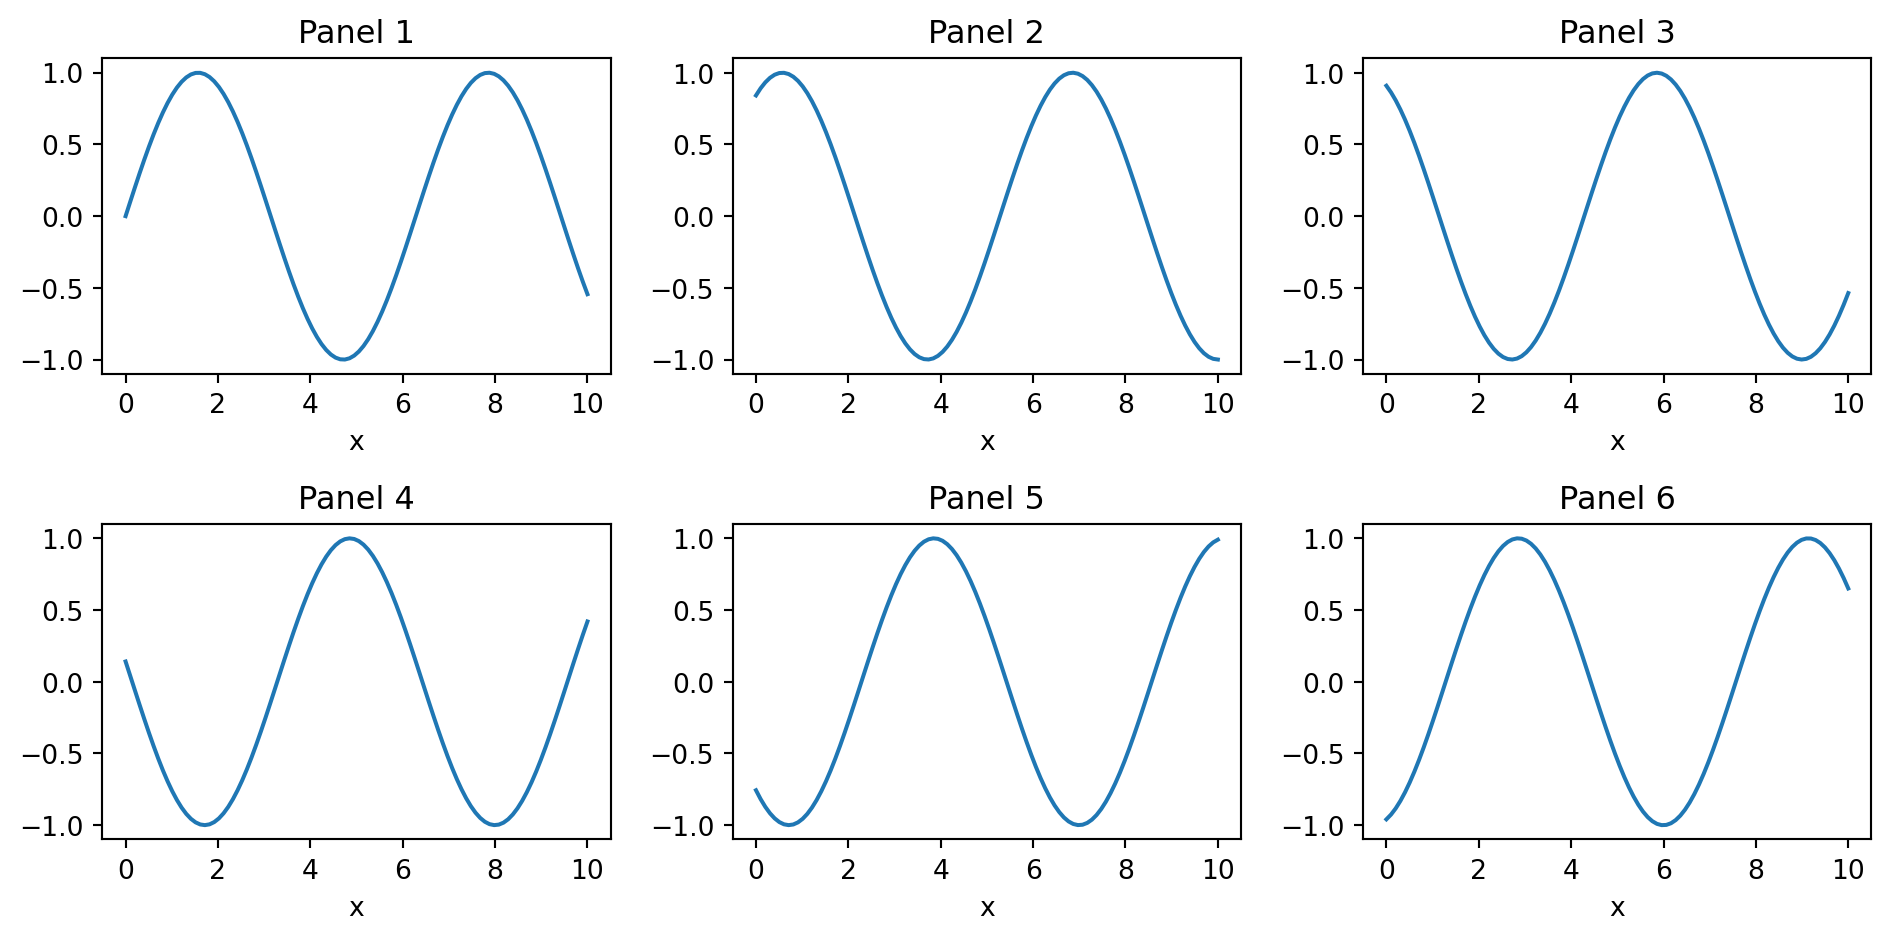

In [3]:
fig, axes = plt.subplots(2, 3, figsize=(10, 5))

for i, ax in enumerate(axes.flat):
    ax.plot(x, np.sin(x + i))
    ax.set_title(f"Panel {i + 1}")
    ax.set_xlabel("x")

fig.tight_layout()
plt.show()

### Looping over data and panels together

Faceted plotting in matplotlib is usually a `for` loop.

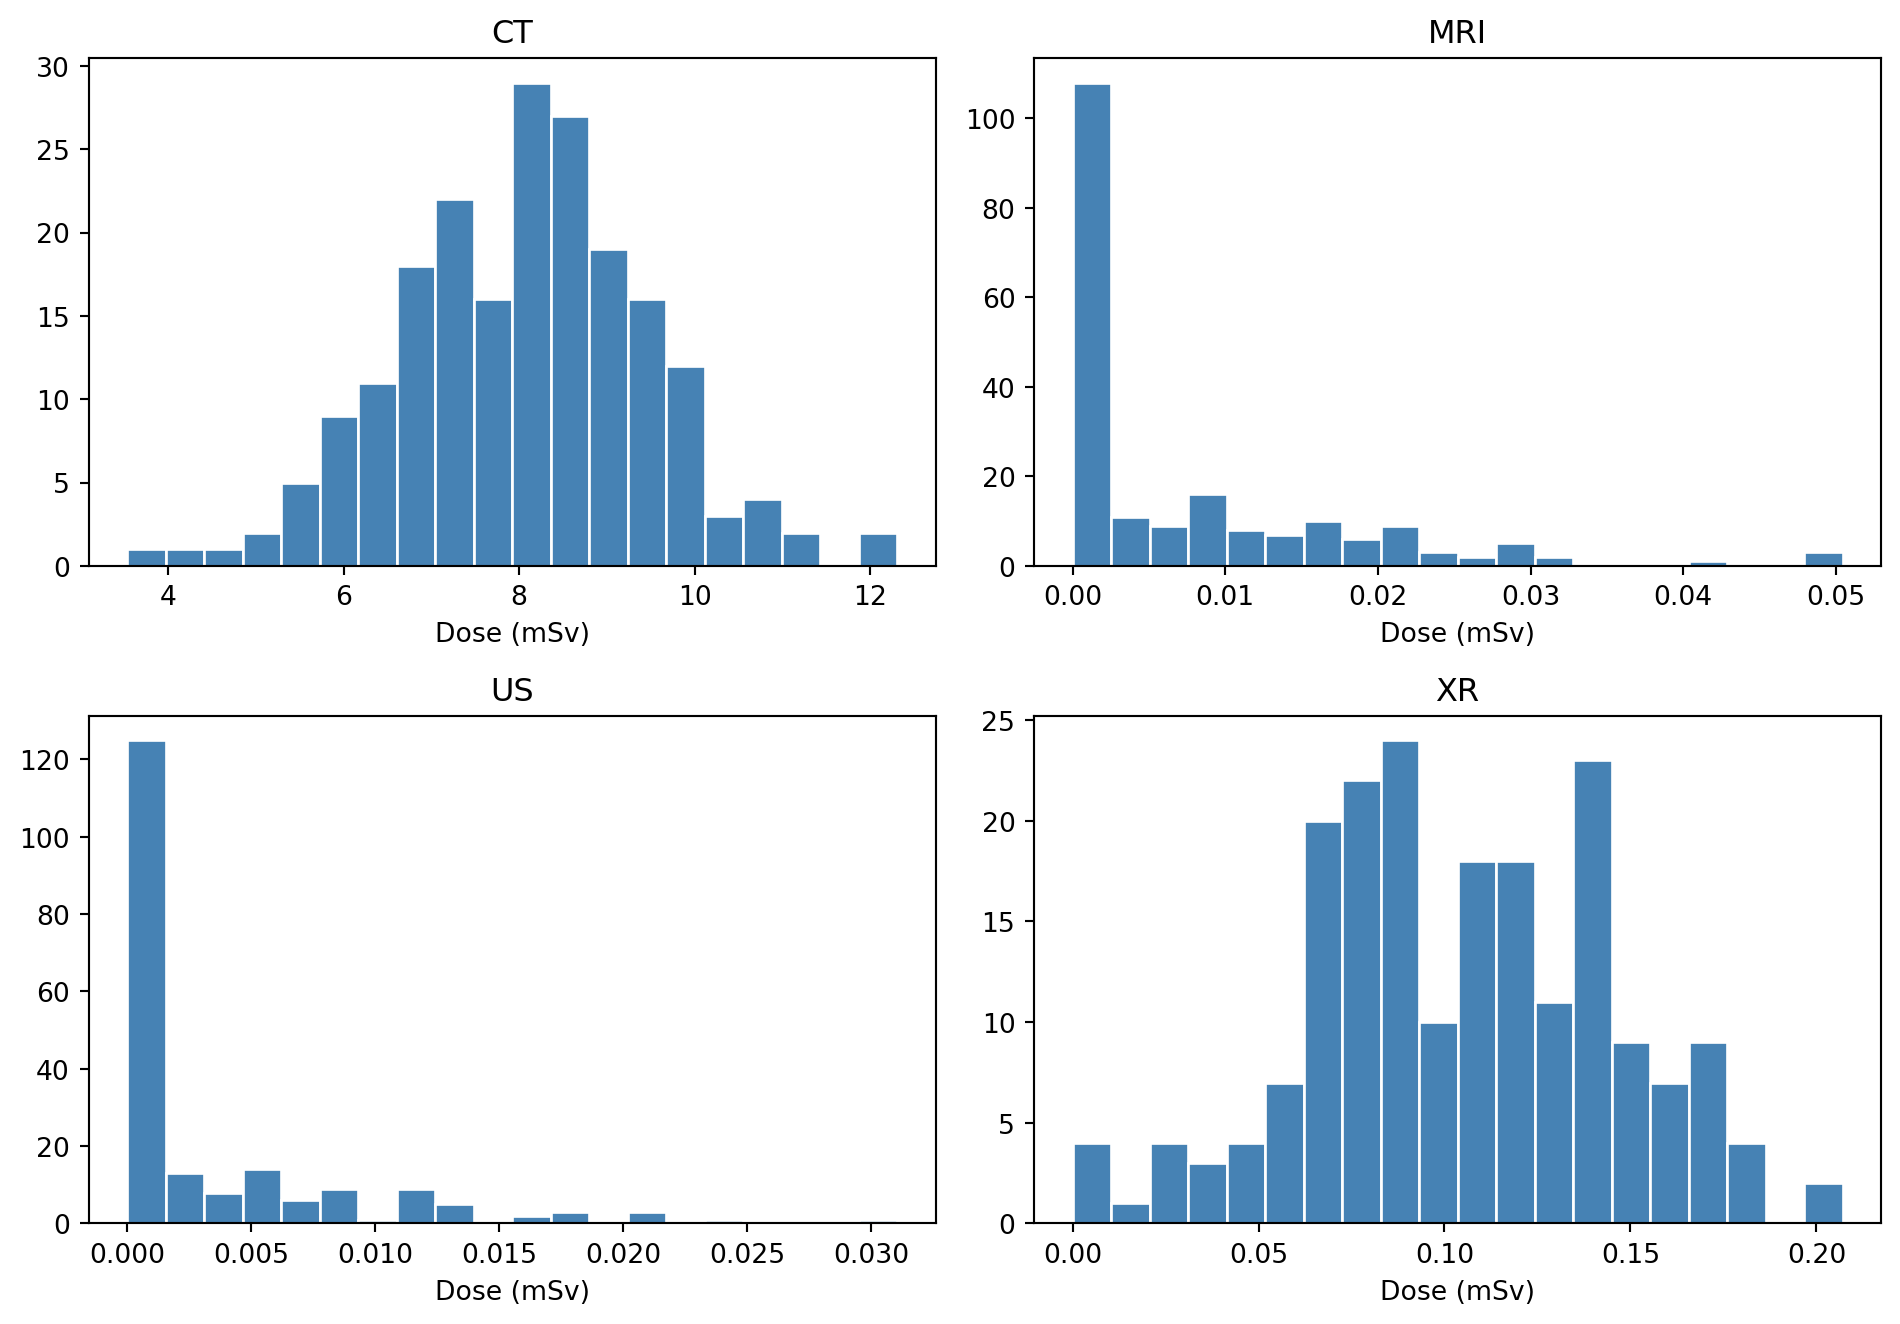

In [4]:
def simulate_dose_data(modality, n=200, seed=0):
    rng = np.random.default_rng(seed + hash(modality) % 1000)
    params = {
        "CT": (8.0, 1.5),
        "MRI": (0.0, 0.02),
        "US": (0.0, 0.01),
        "XR": (0.10, 0.04),
    }
    mean, sd = params[modality]
    return np.clip(rng.normal(mean, sd, n), 0, None)

modalities = ["CT", "MRI", "US", "XR"]
fig, axes = plt.subplots(2, 2, figsize=(10, 7))

for ax, modality in zip(axes.flat, modalities):
    data = simulate_dose_data(modality)
    ax.hist(data, bins=20, color="steelblue", edgecolor="white")
    ax.set_title(modality)
    ax.set_xlabel("Dose (mSv)")

fig.tight_layout()
plt.show()

This is the matplotlib equivalent of `facet_wrap(~ modality)`. It is verbose, but it gives full control over each panel. If one modality needs a different x-range or annotation, use a normal `if` block inside the loop.

## 2. Shared axes: `sharex` and `sharey`

When panels show the same kind of data, shared scales make comparison easier.

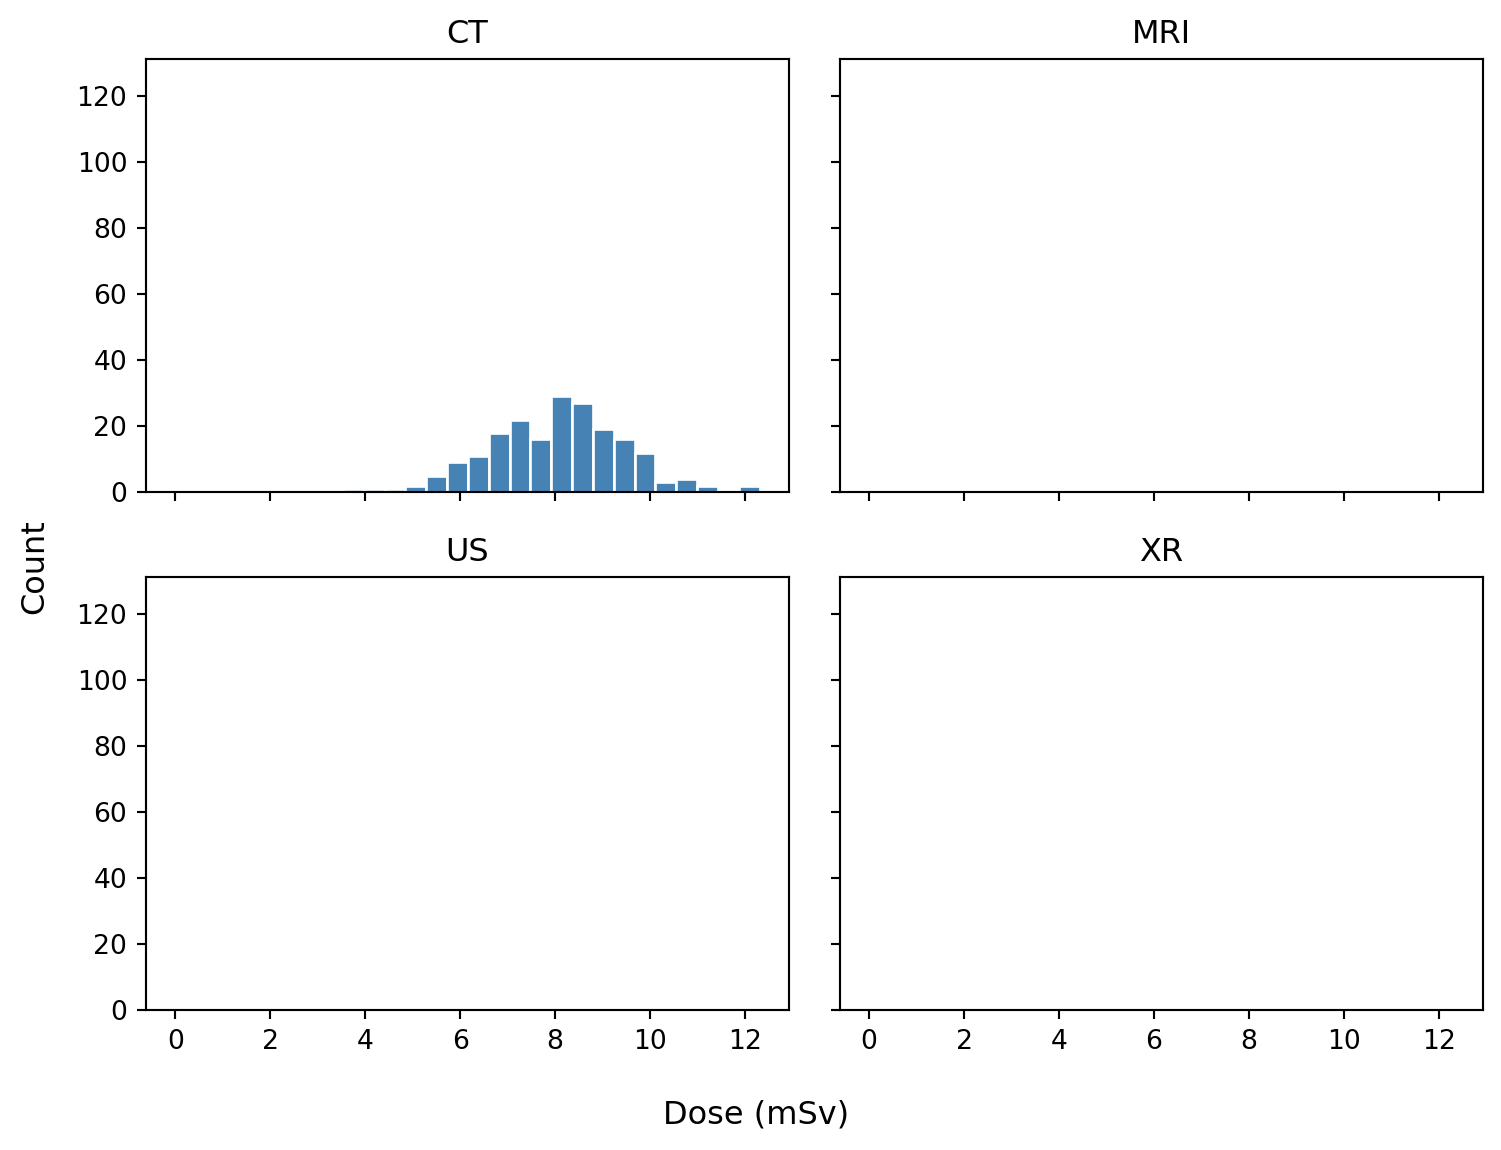

In [5]:
fig, axes = plt.subplots(
    2,
    2,
    figsize=(8, 6),
    sharex=True,
    sharey=True,
)

for ax, modality in zip(axes.flat, modalities):
    data = simulate_dose_data(modality)
    ax.hist(data, bins=20, color="steelblue", edgecolor="white")
    ax.set_title(modality)

fig.supxlabel("Dose (mSv)")
fig.supylabel("Count")
fig.tight_layout()
plt.show()

With `sharex=True`, all panels use the same x-range, and matplotlib automatically hides repeated x tick labels except on the bottom row. `sharey=True` does the same for the y-axis.

Shared axes are useful when the reader should compare panels directly. Avoid sharing axes when panels genuinely need different scales to reveal different structures.

Shared versus independent y-axes:

```text
sharey=True                         sharey=False (default)
─────────────────                   ─────────────────
20│ ┌──────┐ ┌──────┐              20│ ┌──────┐   5│ ┌──────┐
10│ │  ╱   │ │  ╱╲  │              10│ │  ╱   │   3│ │  ╱╲  │
 0└─┴──────┘ └──────┘               0└─┴──────┘   0└─┴──────┘
   panels comparable                    panels independent
```

For more control, specific axes can be shared after creation:

```python
fig, axes = plt.subplots(1, 3)
axes[1].sharey(axes[0])
axes[2].sharey(axes[0])
```

After sharing, zooming or changing limits on one shared axis affects the others.

## 3. `subplot_mosaic`: the modern favorite

For irregular layouts, `subplot_mosaic()` is often more readable than `GridSpec`. You describe the layout as a string or list, and panels are returned as a dictionary keyed by name.

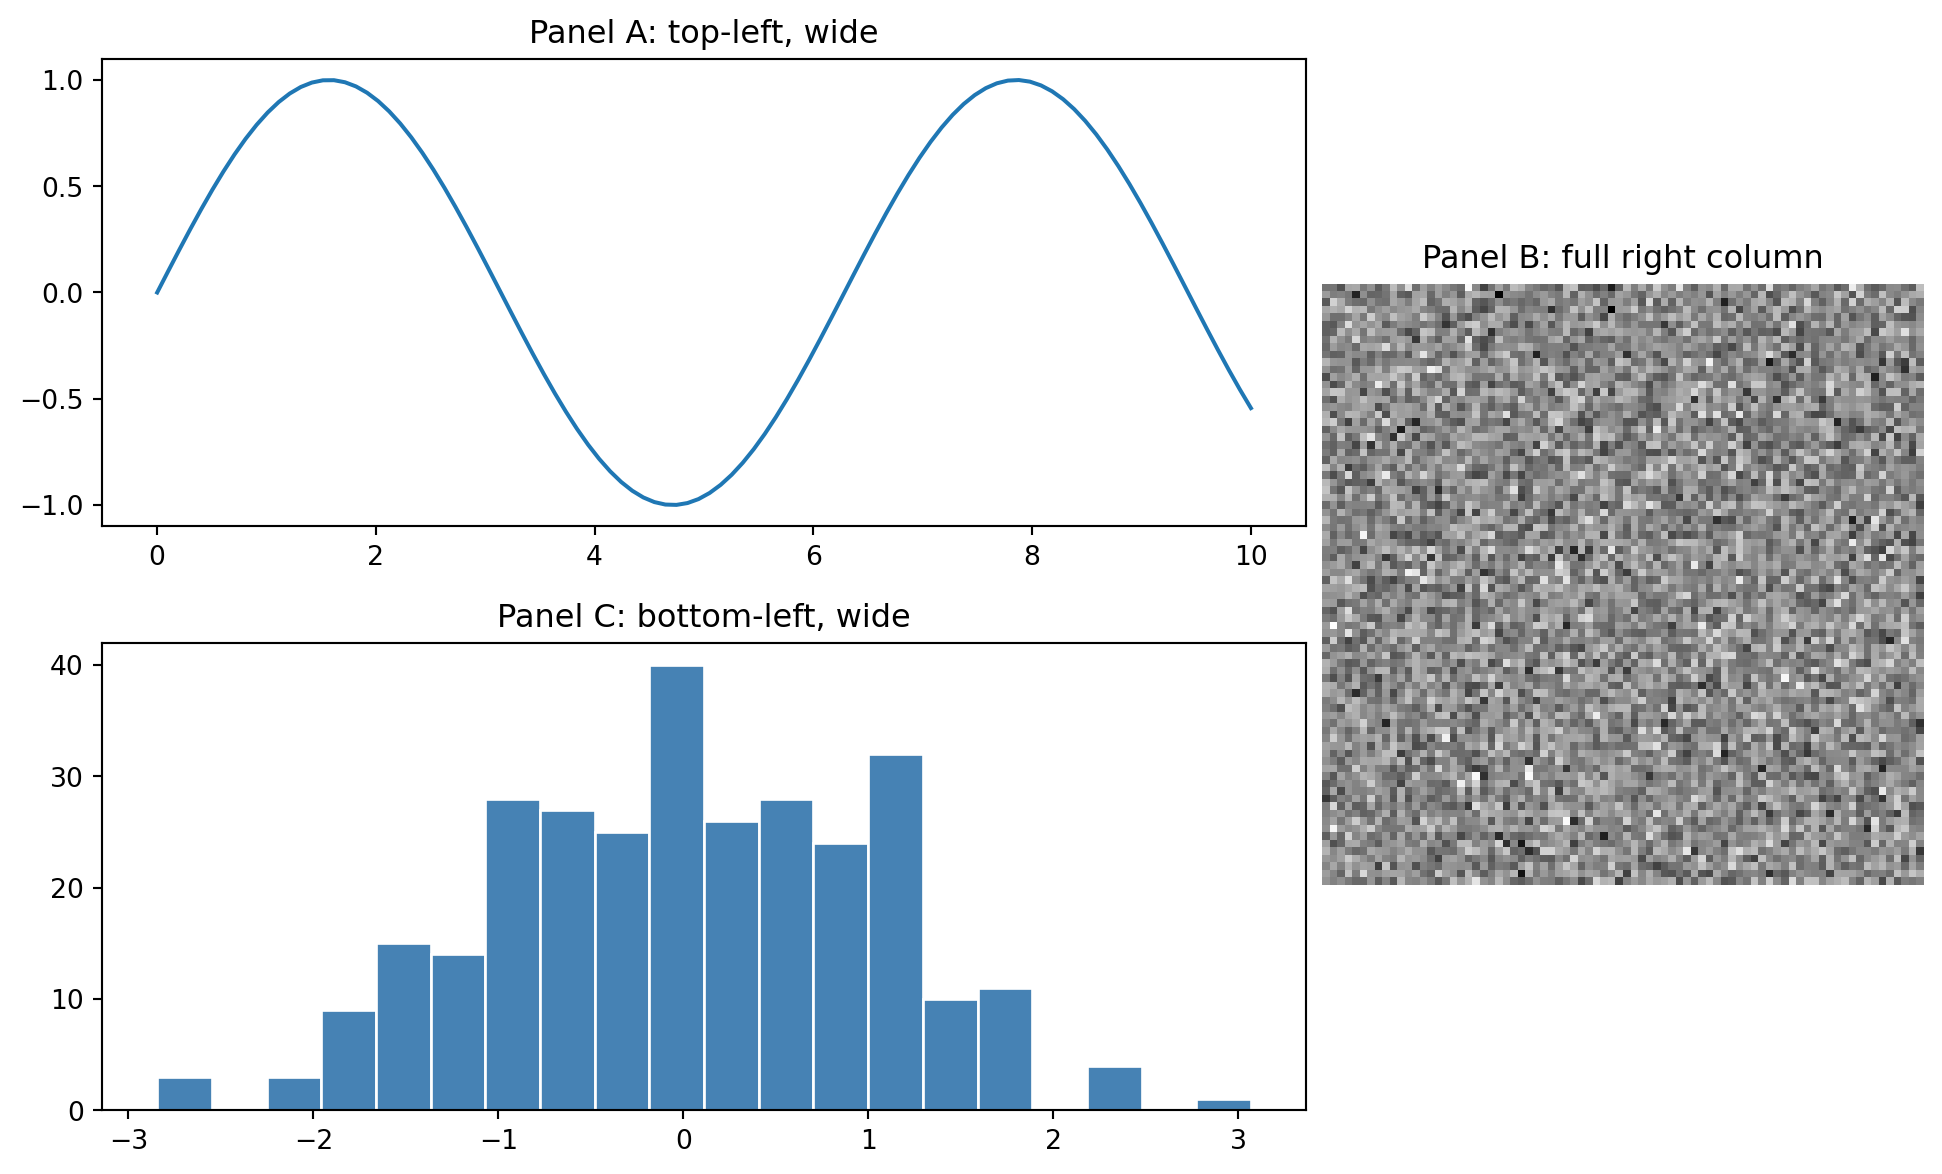

In [6]:
image_data = rng.normal(0, 1, size=(80, 80))
values = rng.normal(size=300)

fig, axd = plt.subplot_mosaic(
    """
    AAB
    CCB
    """,
    figsize=(10, 6),
    layout="constrained",
)

axd["A"].plot(x, np.sin(x))
axd["A"].set_title("Panel A: top-left, wide")

axd["B"].imshow(image_data, cmap="gray")
axd["B"].set_title("Panel B: full right column")
axd["B"].axis("off")

axd["C"].hist(values, bins=20, color="steelblue", edgecolor="white")
axd["C"].set_title("Panel C: bottom-left, wide")

plt.show()

The mosaic string `"AAB / CCB"` produces this layout:

```text
┌───────────────┬───────┐
│               │       │
│       A       │       │
│               │       │
├───────────────┤   B   │
│               │       │
│       C       │       │
│               │       │
└───────────────┴───────┘
```

Each character is one cell in a grid. Repeating a character makes that panel span cells. Use `.` for empty cells:

```python
"""
AAB
.CB
"""
```

This makes many irregular layouts simple and readable.

### The radiology pattern: image + colorbar + plot

A common publication layout has a large image, a dedicated colorbar slot, and a side panel for a quantitative plot.

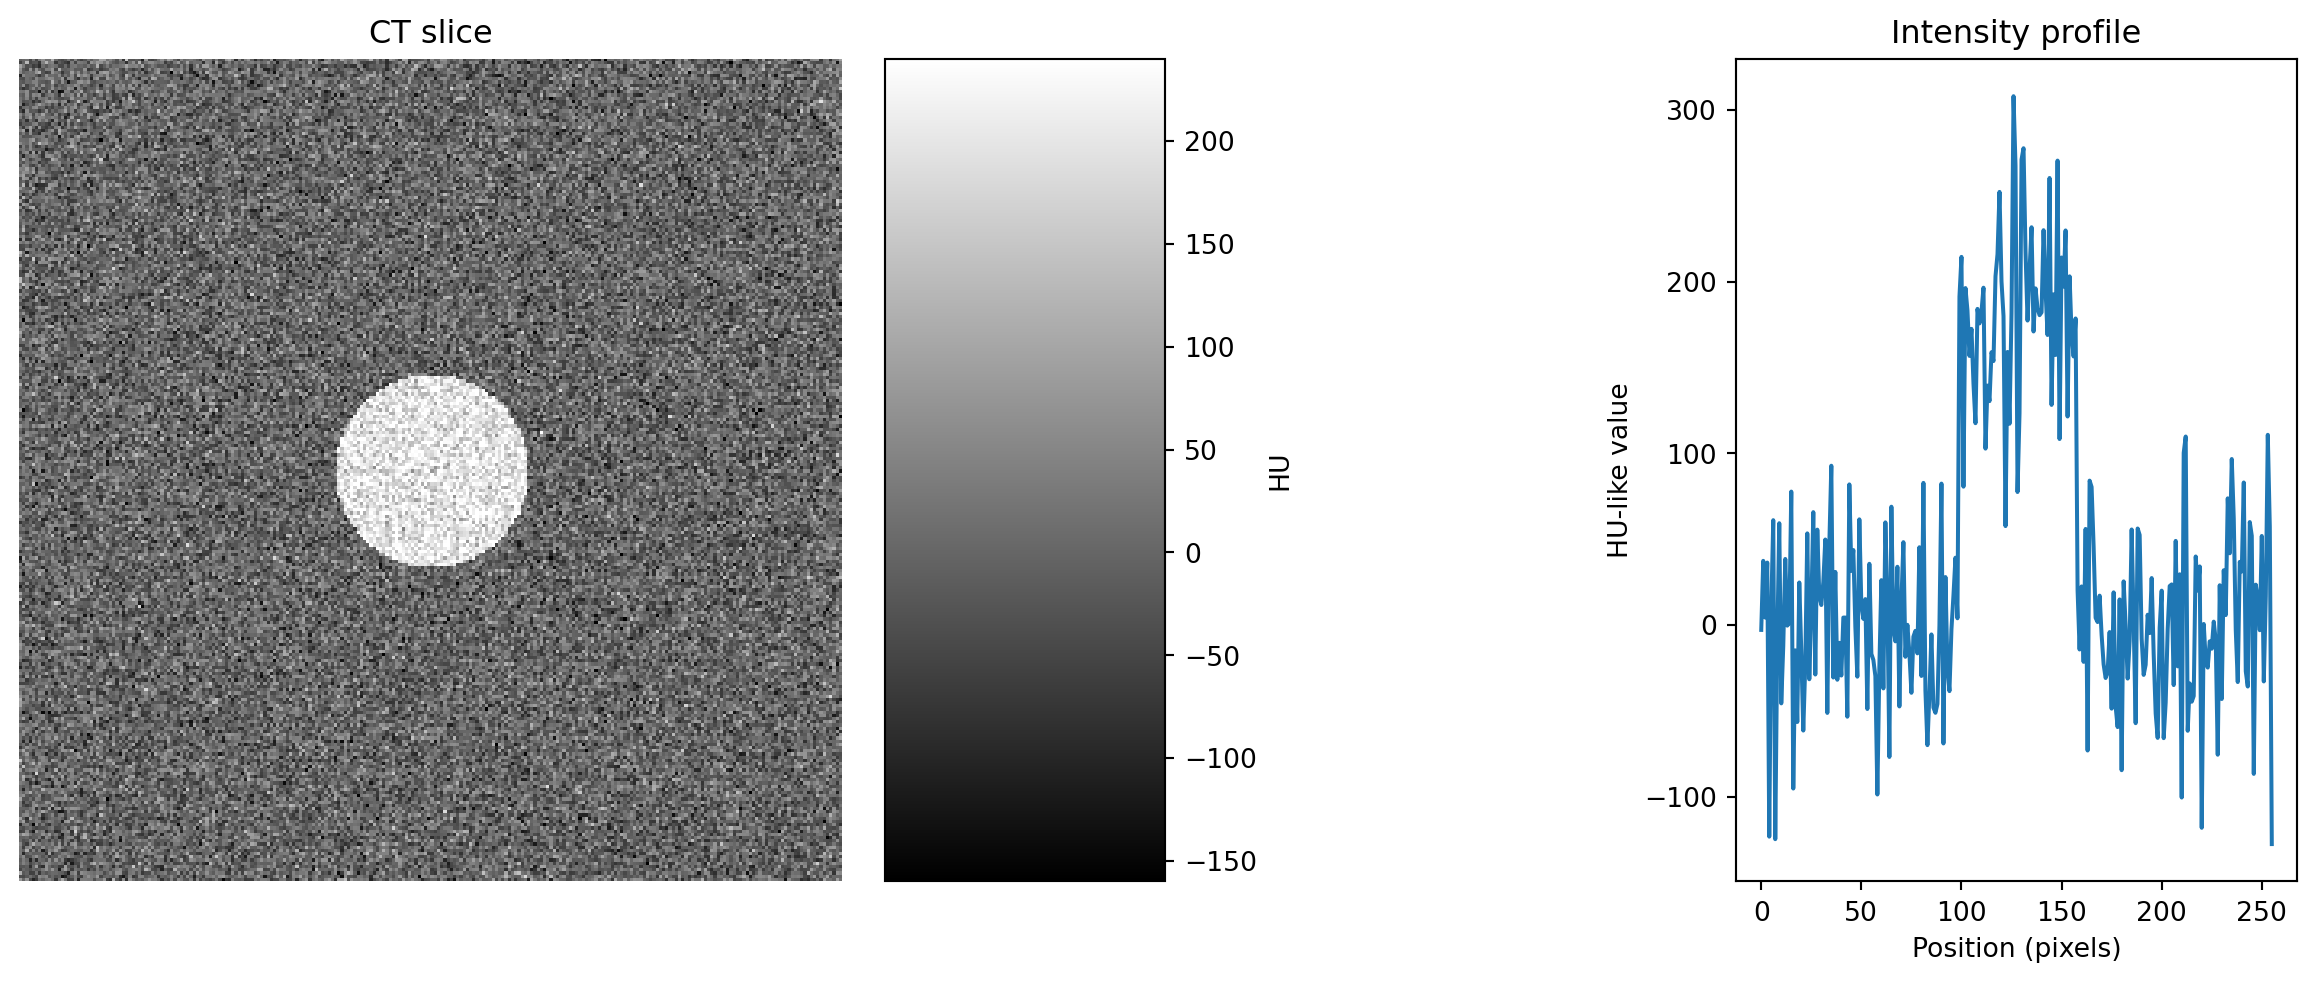

In [7]:
slice_2d = rng.normal(0, 50, (256, 256))
yy, xx = np.ogrid[:256, :256]
slice_2d[(xx - 128) ** 2 + (yy - 128) ** 2 < 30 ** 2] += 200
profile_x = np.arange(slice_2d.shape[1])
profile_y = slice_2d[128, :]

fig, axd = plt.subplot_mosaic(
    """
    IIIC.PP
    IIIC.PP
    IIIC.PP
    """,
    figsize=(12, 5),
    gridspec_kw={"wspace": 0.1},
    layout="constrained",
)

im = axd["I"].imshow(slice_2d, cmap="gray", vmin=-160, vmax=240)
axd["I"].set_title("CT slice")
axd["I"].axis("off")

fig.colorbar(im, cax=axd["C"], label="HU")

axd["P"].plot(profile_x, profile_y)
axd["P"].set_title("Intensity profile")
axd["P"].set_xlabel("Position (pixels)")
axd["P"].set_ylabel("HU-like value")

plt.show()

`cax=` tells `colorbar()` to draw into an existing `Axes`. This is different from `ax=`, which tells matplotlib which axes to steal space from.

That distinction is the trick for placing a colorbar exactly where it should go.

## 4. `GridSpec`: when mosaic is not enough

`GridSpec` is the lower-level layout engine behind `subplots()` and `subplot_mosaic()`.

Reach for it when you need:

- different relative widths or heights per row/column
- programmatic generation of a grid from computed positions
- fine control beyond what a mosaic string can express

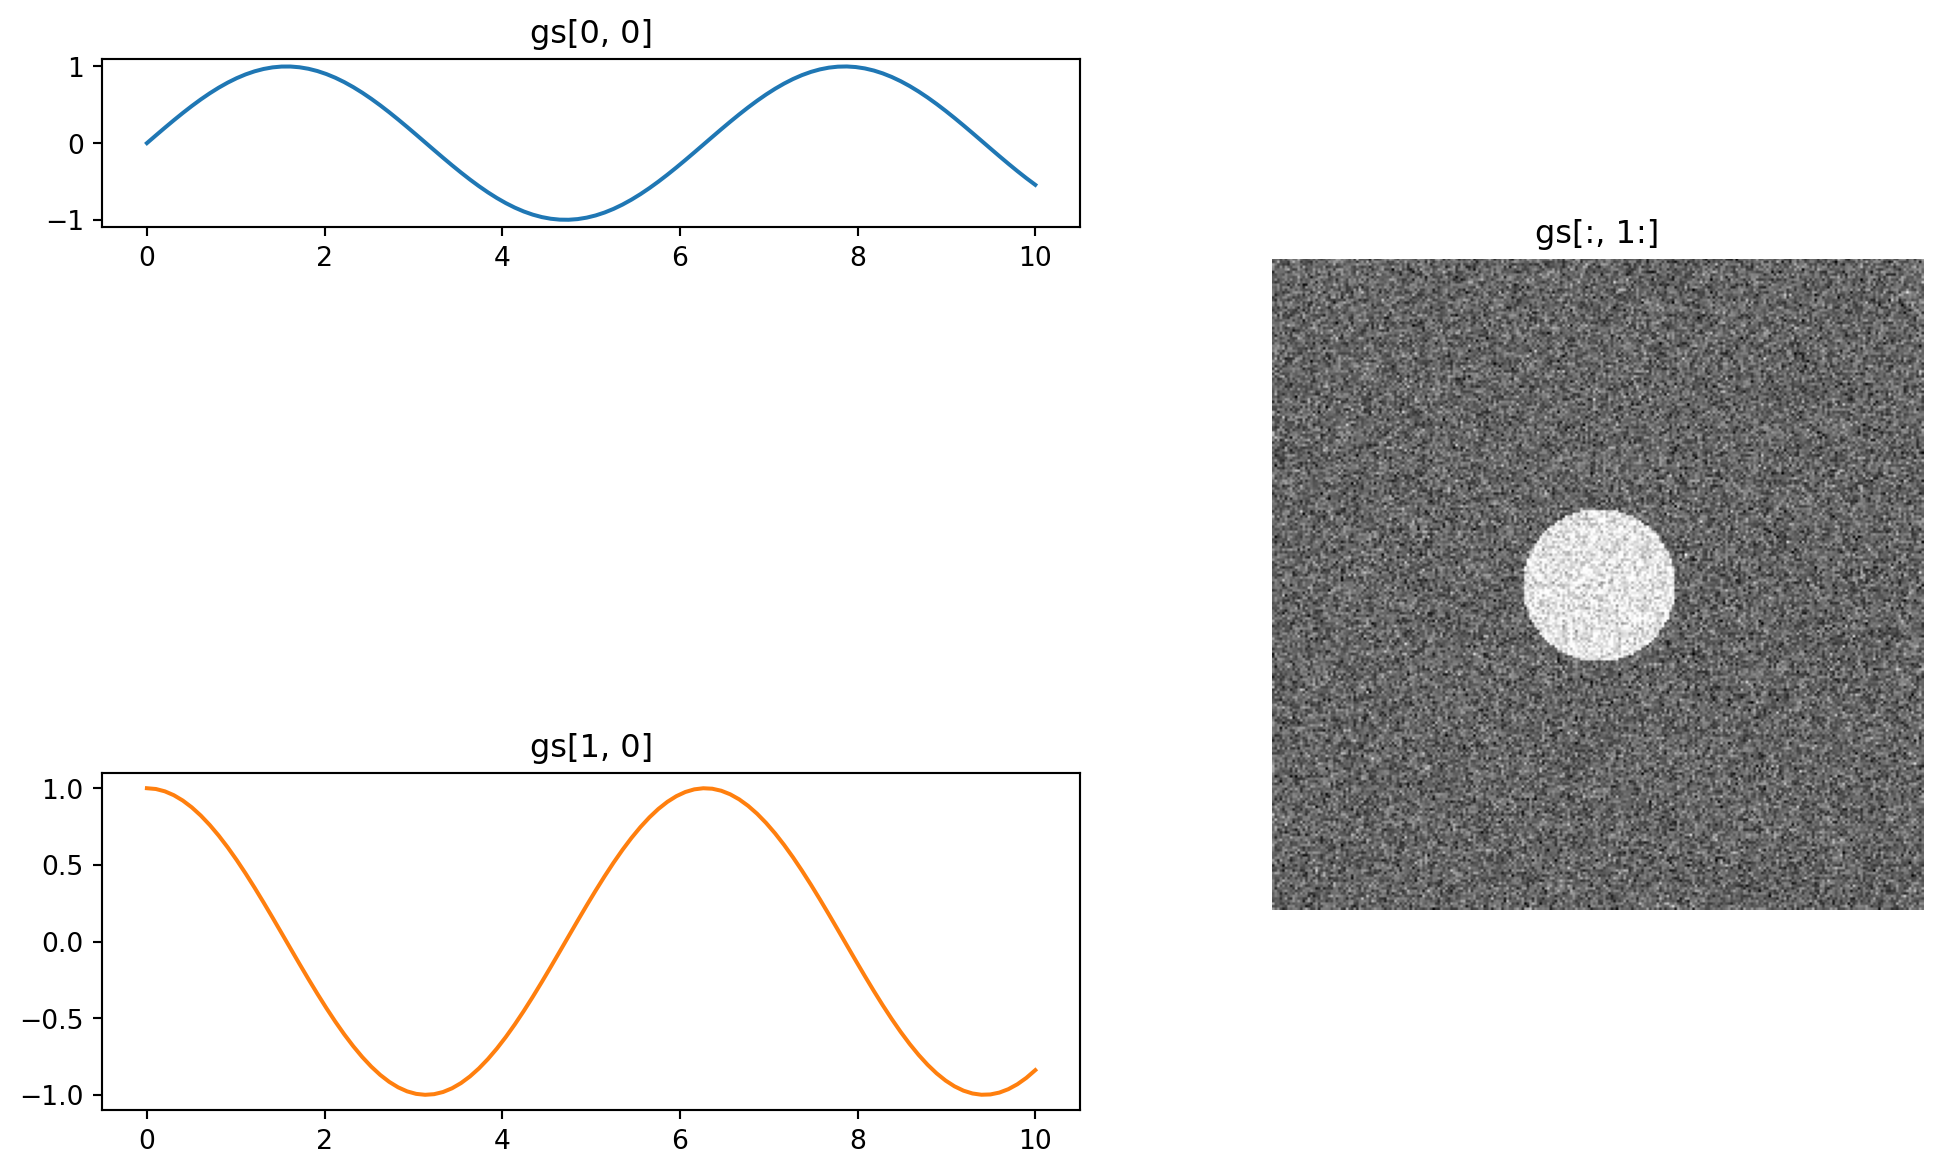

In [8]:
import matplotlib.gridspec as gridspec

fig = plt.figure(figsize=(10, 6), layout="constrained")
gs = gridspec.GridSpec(
    2,
    3,
    figure=fig,
    width_ratios=[3, 1, 1],
    height_ratios=[1, 2],
    wspace=0.3,
    hspace=0.4,
)

ax1 = fig.add_subplot(gs[0, 0])   # top-left
ax2 = fig.add_subplot(gs[1, 0])   # bottom-left
ax3 = fig.add_subplot(gs[:, 1:])  # right side, all rows

ax1.plot(x, np.sin(x))
ax1.set_title("gs[0, 0]")

ax2.plot(x, np.cos(x), color="C1")
ax2.set_title("gs[1, 0]")

ax3.imshow(slice_2d, cmap="gray", vmin=-160, vmax=240)
ax3.set_title("gs[:, 1:]")
ax3.axis("off")

plt.show()

`GridSpec` slicing works like NumPy slicing:

```text
gs[0, 0]     one cell, top-left
gs[0, :]     entire top row
gs[:, 0]     entire left column
gs[1:, 1:]   bottom-right block
gs[0, 1:3]   top row, columns 1 and 2
```

For most use cases, `subplot_mosaic()` covers the same ground more readably. Use `GridSpec` mainly when widths or heights need to be uneven or computed programmatically.

## 5. Inset axes: a small plot inside a big plot

Insets are useful for zoom-in views, small legends, or local statistics.

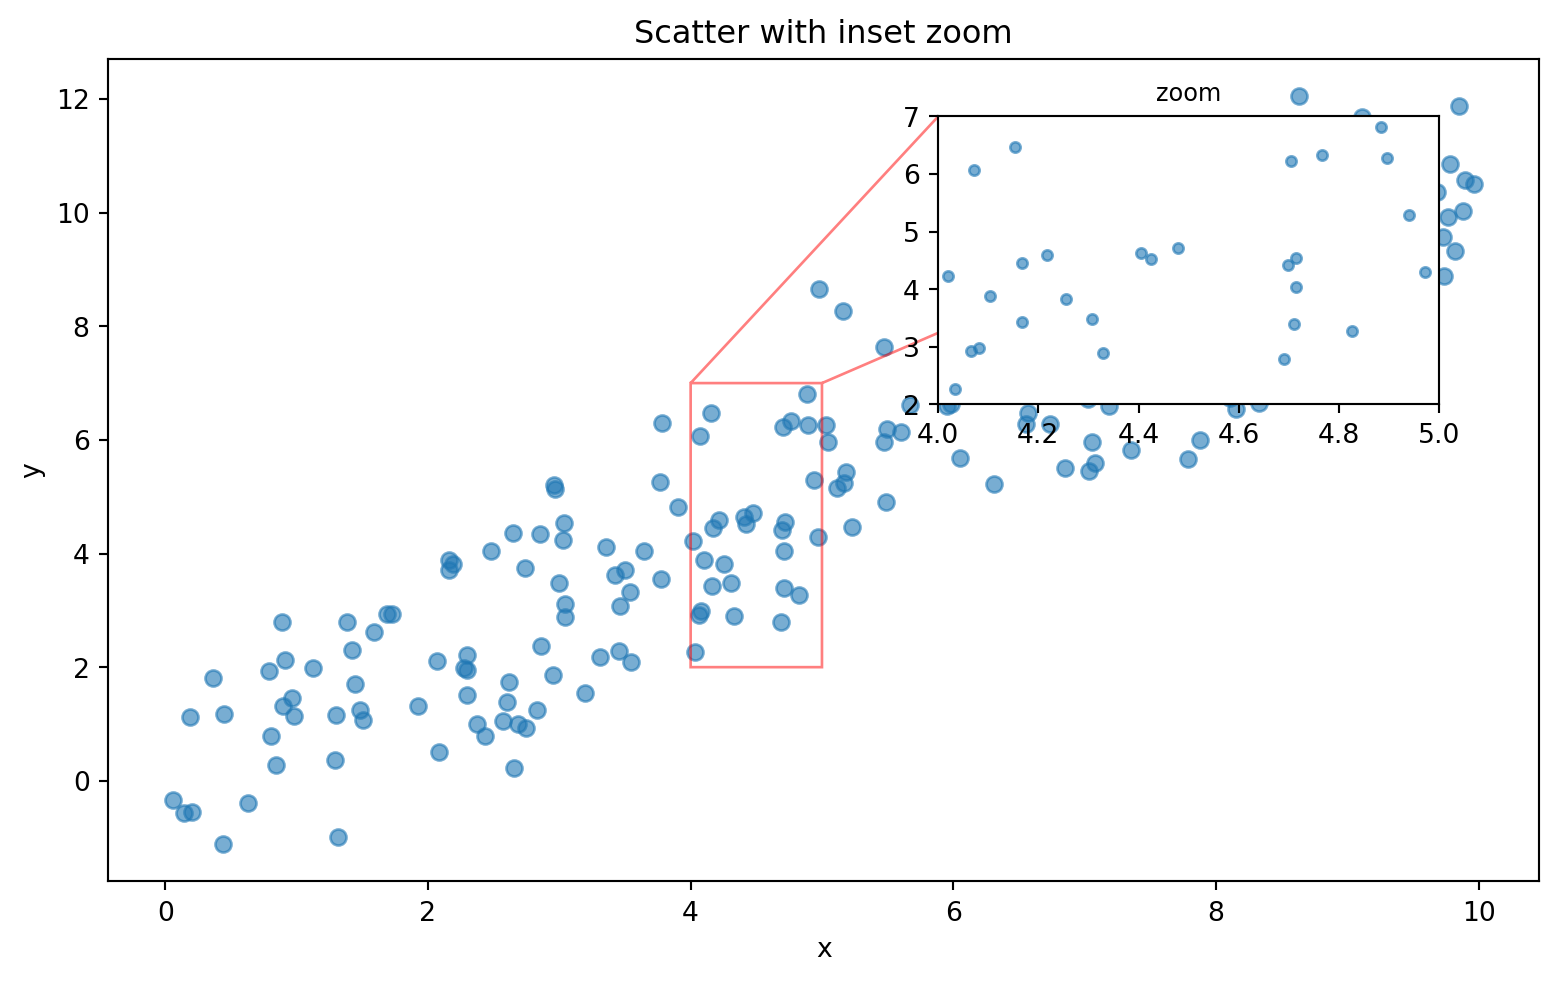

In [9]:
x_scatter = rng.uniform(0, 10, 200)
y_scatter = x_scatter + rng.normal(0, 1.2, 200)

fig, ax = plt.subplots(figsize=(8, 5), layout="constrained")
ax.scatter(x_scatter, y_scatter, alpha=0.6)
ax.set_xlabel("x")
ax.set_ylabel("y")
ax.set_title("Scatter with inset zoom")

# Inset relative to the parent axes: [left, bottom, width, height]
inset = ax.inset_axes([0.58, 0.58, 0.35, 0.35])
inset.scatter(x_scatter, y_scatter, alpha=0.6, s=15)
inset.set_xlim(4, 5)
inset.set_ylim(2, 7)
inset.set_title("zoom", fontsize=9)

ax.indicate_inset_zoom(inset, edgecolor="red")
plt.show()

Two clean approaches:

```python
# Way 1: absolute figure coordinates, all in 0–1 of the figure
inset = fig.add_axes([0.6, 0.6, 0.25, 0.25])

# Way 2: relative to the parent axes, often more useful
inset = ax.inset_axes([0.6, 0.6, 0.35, 0.35])
```

`ax.indicate_inset_zoom()` is especially helpful: it draws the rectangle and connecting lines automatically after the inset limits define the zoomed region.

## 6. Spacing and layout

Panel spacing is a perennial matplotlib headache. Three layout approaches matter:

```python
fig.tight_layout()                    # classic, adjusts after the fact
fig.set_layout_engine("constrained")  # newer, smarter layout engine
plt.subplots(..., layout="constrained")
```

```text
Layout managers
─────────────────────────────────────────
tight_layout    Old standard. Usually fine, but can glitch with colorbars.

constrained     Newer and more robust. Handles colorbars, suptitles,
                and shared axes better. Usually the right choice.

manual          fig.subplots_adjust(left=, right=, ...)
                Use only when exact control is needed.
```

For modern code, prefer:

```python
fig, axes = plt.subplots(2, 2, figsize=(10, 7), layout="constrained")
```

For fine-tuning, `wspace` and `hspace` control gaps between panels:

```python
fig, axes = plt.subplots(2, 2, gridspec_kw={"wspace": 0.4, "hspace": 0.5})
```

## 7. A super-title above everything

`fig.suptitle()` titles the whole figure. Each `ax.set_title()` titles one panel.

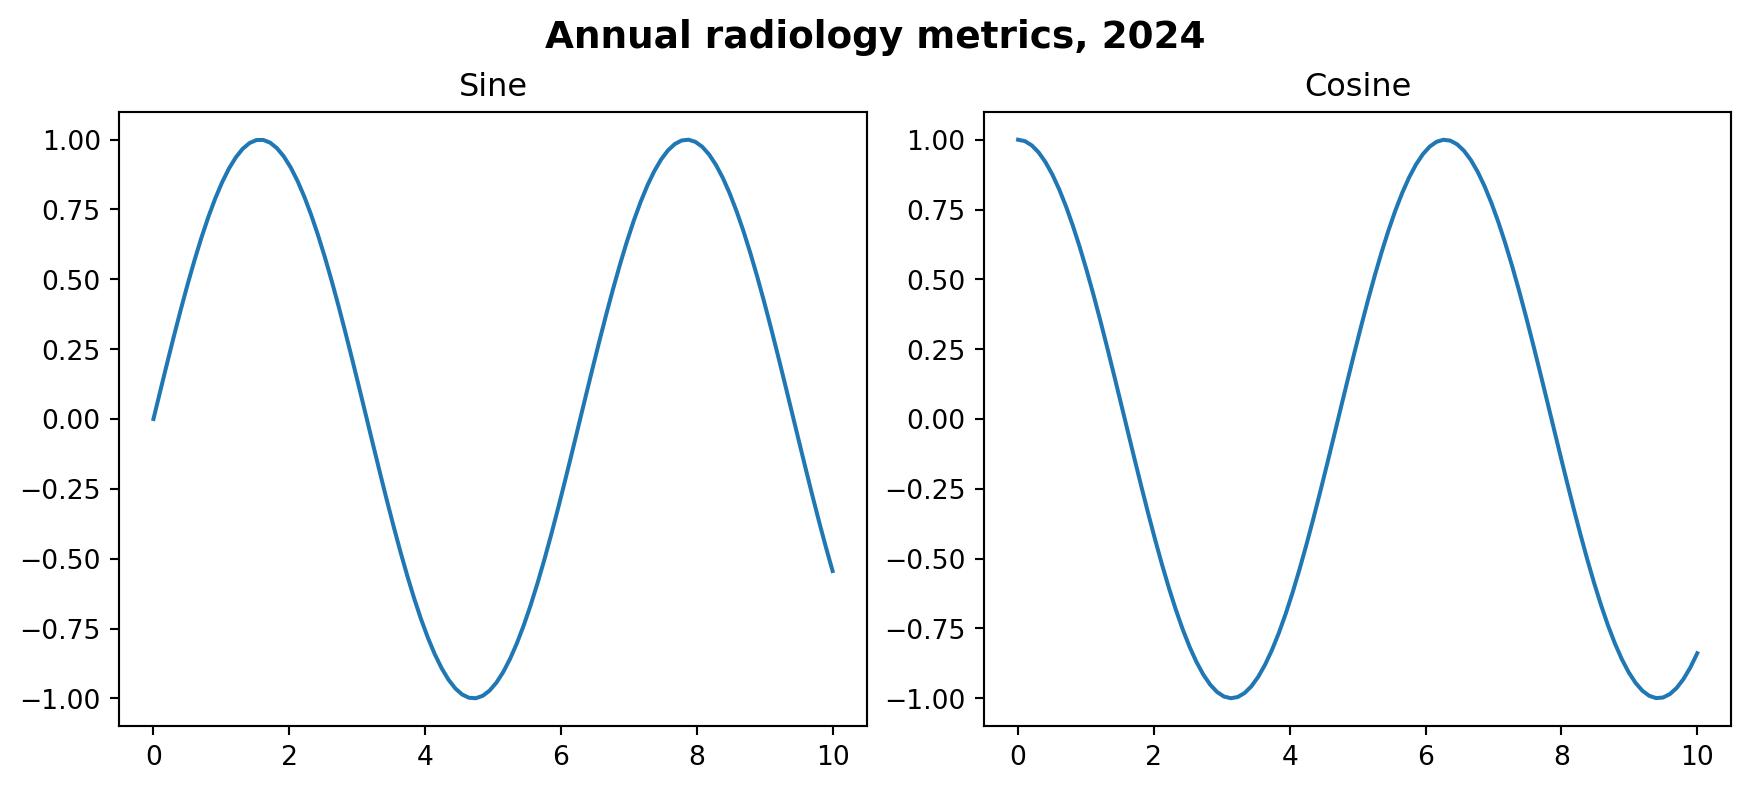

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(9, 4), layout="constrained")
axes[0].plot(x, np.sin(x))
axes[0].set_title("Sine")
axes[1].plot(x, np.cos(x))
axes[1].set_title("Cosine")

fig.suptitle("Annual radiology metrics, 2024", fontsize=14, fontweight="bold")
plt.show()

With `layout="constrained"`, suptitles and panel titles usually coexist without overlap.

## 8. Complete example: radiology dashboard

This 2×2 dashboard combines several patterns from the module.

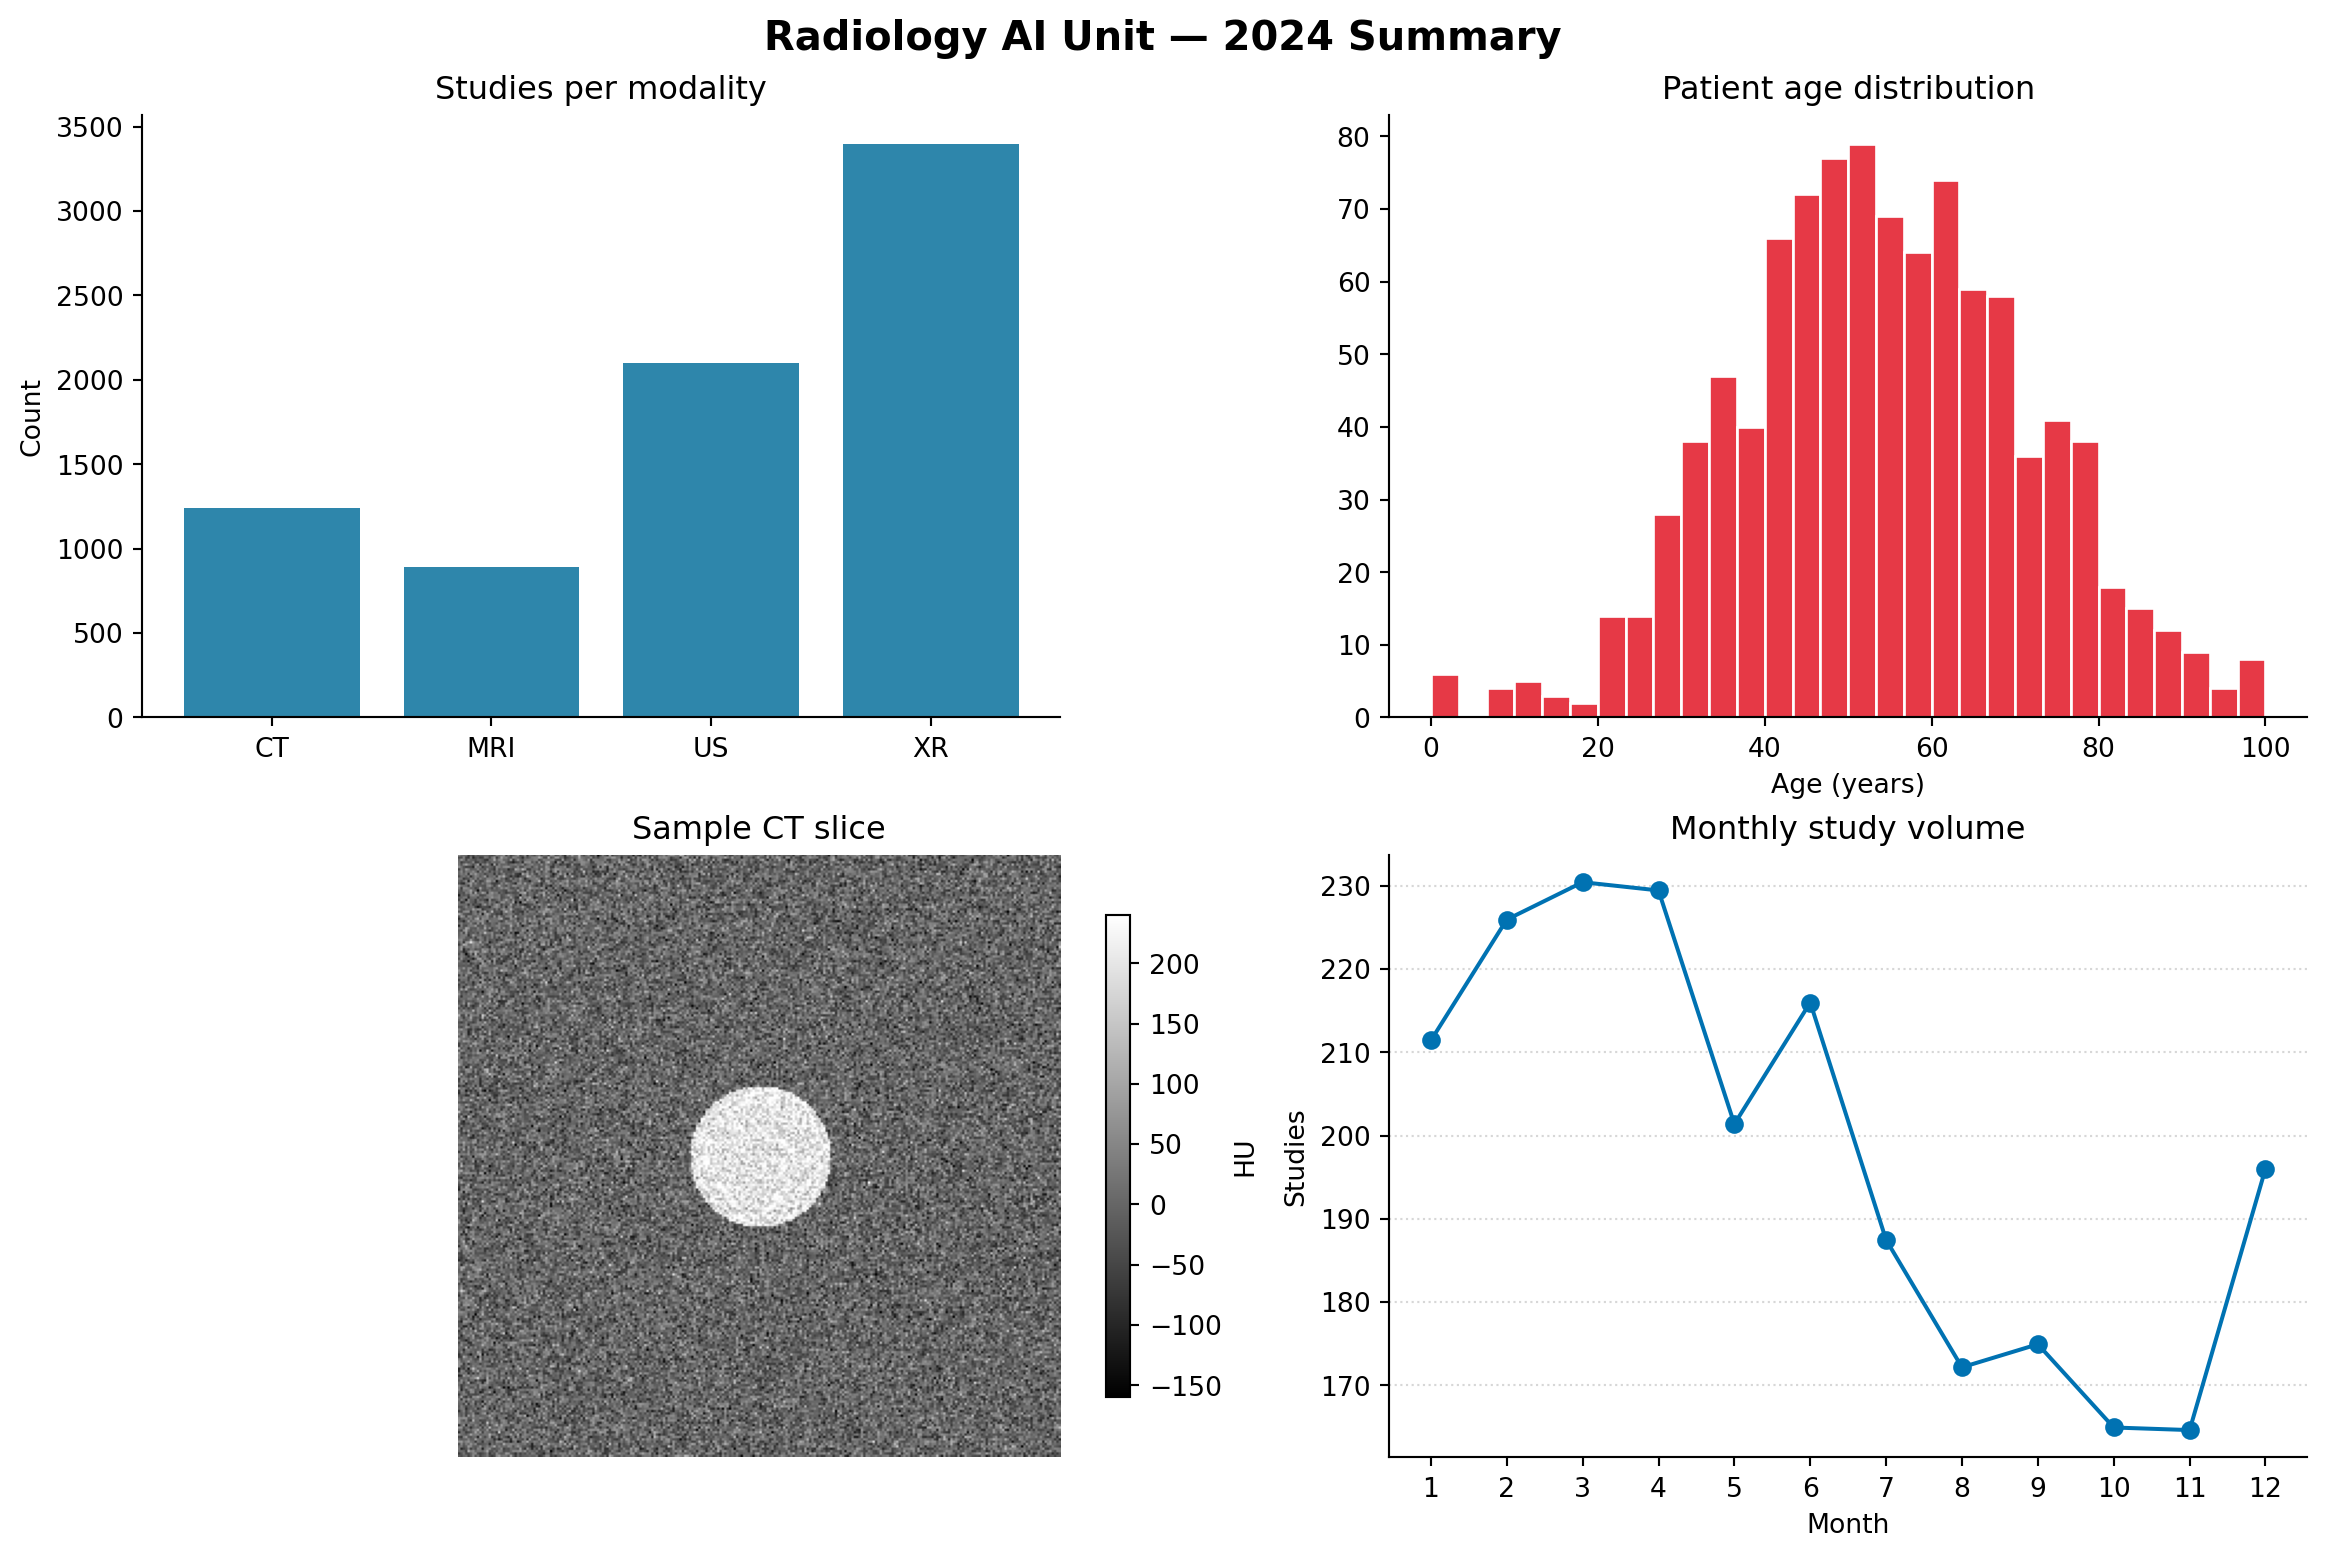

In [11]:
rng = np.random.default_rng(0)

# Simulated data
modalities = ["CT", "MRI", "US", "XR"]
counts = [1240, 890, 2100, 3400]
ages = rng.normal(55, 18, 1000).clip(0, 100)
slice_2d = rng.normal(0, 50, (256, 256))
yy, xx = np.ogrid[:256, :256]
slice_2d[(xx - 128) ** 2 + (yy - 128) ** 2 < 30 ** 2] += 200
months = np.arange(1, 13)
volume = 200 + 30 * np.sin(months / 2) + rng.normal(0, 10, 12)

fig, axd = plt.subplot_mosaic(
    """
    AB
    CD
    """,
    figsize=(12, 8),
    layout="constrained",
)

# A: bar chart
axd["A"].bar(modalities, counts, color="#2E86AB")
axd["A"].set_title("Studies per modality")
axd["A"].set_ylabel("Count")
axd["A"].spines[["top", "right"]].set_visible(False)

# B: histogram
axd["B"].hist(ages, bins=30, color="#E63946", edgecolor="white")
axd["B"].set_title("Patient age distribution")
axd["B"].set_xlabel("Age (years)")
axd["B"].spines[["top", "right"]].set_visible(False)

# C: image with colorbar
im = axd["C"].imshow(slice_2d, cmap="gray", vmin=-160, vmax=240)
axd["C"].set_title("Sample CT slice")
axd["C"].axis("off")
fig.colorbar(im, ax=axd["C"], shrink=0.8, label="HU")

# D: time series
axd["D"].plot(months, volume, marker="o", color="#0072B2")
axd["D"].set_title("Monthly study volume")
axd["D"].set_xlabel("Month")
axd["D"].set_ylabel("Studies")
axd["D"].set_xticks(months)
axd["D"].spines[["top", "right"]].set_visible(False)
axd["D"].grid(True, axis="y", linestyle=":", alpha=0.5)

fig.suptitle("Radiology AI Unit — 2024 Summary", fontsize=15, fontweight="bold")
plt.show()

Notice the patterns:

- consistent spine treatment across panels
- consistent palette
- the image gets a colorbar through `fig.colorbar(im, ax=axd["C"])`
- `layout="constrained"` keeps the figure readable without manual spacing tweaks

## ggplot2 → matplotlib multi-panel cheat sheet

| ggplot2 / patchwork | matplotlib |
|---|---|
| `facet_wrap(~ var)` | `plt.subplots()` + for-loop over groups |
| `facet_grid(row ~ col)` | `plt.subplots(nrows, ncols)` + manual loop over row/column/group |
| `patchwork: p1 + p2 / p3` | `plt.subplot_mosaic("AB;CC")` |
| `patchwork: p1 + plot_layout(...)` | `GridSpec(width_ratios=, height_ratios=)` |
| `inset_element(p2, ...)` | `ax.inset_axes(...)` |

The honest difference: ggplot2 plus patchwork is usually more concise for non-trivial layouts. Matplotlib's looser grid gives more independent control over each panel, which matters in scientific publishing.

## Exercises

### Exercise 1

Make a 2×2 grid of histograms, one for each distribution:

- `Normal(0, 1)`
- `Normal(0, 2)`
- `Uniform(-3, 3)`
- `Exponential(1)` using `rng.exponential(1, 200)`

Use `sharex=True` and `sharey=True` so the panels are directly comparable. Title each panel with the distribution name and add `fig.suptitle("Distribution comparison")`.

### Exercise 2

Use `subplot_mosaic()` to create this layout, then populate each panel with a different plot:

```text
AABB
AABB
CCDE
```

A and B are large top panels. C, D, and E are small bottom panels, with C wider than D and E.

### Exercise 3

Create a 1×3 figure showing the same simulated CT slice in three different windows: soft tissue, lung, and bone. Use the width/level to `vmin`/`vmax` conversions from Module 5. Use `sharex` and `sharey` to lock the panels together.

Add one shared colorbar to the right of all three panels. Hint: create an extra axes for the colorbar with `subplot_mosaic()`, such as `"ABCD"` where `D` is the colorbar slot, then pass it using `cax=axd["D"]`.

### Exercise 4

Make a scatter plot with an inset zoom: 200 random points where `y = x + noise` with `x ~ Uniform(0, 10)`. The main plot shows everything. The inset in the top-right corner shows only `x ∈ [4, 5]`.

Use `ax.inset_axes()` and `ax.indicate_inset_zoom()` to draw the connecting lines automatically.

### Exercise 5

Reproduce the 2×2 radiology dashboard from section 8 with two changes:

1. add a fifth panel for a boxplot of dose by modality, using a `subplot_mosaic()` layout of your design
2. make all panels share a common style: consistent font sizes, spine treatment, and color palette

## Key takeaways

- A multi-panel figure is one `Figure` containing multiple `Axes` objects.
- `plt.subplots()` is the default tool for regular grids.
- `axes.flat` is the practical way to loop over panels.
- Faceting in matplotlib is a loop over axes and data groups.
- Use `sharex` and `sharey` when panels should be visually comparable.
- Use `subplot_mosaic()` for readable irregular layouts.
- Use `cax=` when a colorbar should occupy a dedicated axes.
- Prefer `layout="constrained"` for modern multi-panel layout management.
- Use `ax.inset_axes()` for zoomed or contextual inset panels.